# Persistence

> Removal persistence features from calibrated Euclid images.

In [ ]:
# | default_exp euclid.persistence

## Approach

Persistence is an effect whereby the observation of a bright source produces an artefact in subsequent exposures. The most obvious persistence features in Euclid NISP images are near-vertical streaks, due to bright sources in the grism-dispersed (SIR) images that are interleaved with the dithered JHY exposures. The appearance of those bright sources in the un-dispersed exposures also produces roughly circular persistence features.

This approach attempts to identify and remove persistence features using only the calibrated J-, H-, Y-band and SIR exposures available in the science archive, i.e. with no access to calibrations. It uses the idea that persistence signals (from the current and previous observation ROSs) should be present in each exposure, but with some decay over time. The sky sources move between dithers, so taking the minimum value over a stack of sequential dithers (which can extend across multiple observation ROSs), produces an estimate of the persistence. Since the persistence features are decaying, the minimum will typically correspond to the time of the last image in the sequence, but to be more precise we use the time corresponding to the minimum flux for each pixel. We only stack images for a single filter at a time, as they have different background levels and each JHY sequence is taken with (almost) the same pointing (so they do not help with rejecting sky sources).

If no persistence features were created during the exposure sequence, then the above approach would suffice. However, if a feature is created in the middle of a stack, then the minimum flux will occur _before_ the persistence appeared, and hence not provide any information about the persistence. Conversely, if a persistence feature does not appear until after the target image (which we want to correct), then we do not want to include the persistence feature. We therefore need to mask pixels in the stack depending on when the persistence feature is created. To do so, we identify recently-formed persistence features. This was originally done using the the DQ image, but now the images themselves are thresholded. We record the latest time a persistence feature is flagged for each pixel in the image. If that time is equal to or prior to the target image, then we mask pixels earlier in the stack. If it is after the target image, then we mask pixels later in the stack. Finally, we need to completely mask any pixels where there are fewer than three unmasked pixels remaining in the stack, since the minimum may be contaminated by sky sources.

At this point we have, for each pixel, an estimate for the persistence flux, the time since the last persistence feature was created (if it occurred within the sequence), and the time between the target exposure (which we want to correct) and our persistence estimate.

The persistence estimate is lower than the true persistence in the target image, since the persistence has decayed in the intervening time. Simply subtracting the persistence estimate from the target image would be an improvement, but would not remove all of the persistence. However, if we can model the decay, then we can rescale the persistence estimate to the time of the target image.

To determine a suitable model, we combine all the persistence estimates and run source detection to find the bright features. We then plot the log(flux) of each feature against the time since the persistence feature was created. These results show that the flux decay is well modelled by a power-law. The slope (power-law index) varies from feature to feature. This may reflect different decay rates depending on position on the detector, brightness of the originating source, etc. This warrants further attention and could improve the correction. However, as a simple first approach, we take a rough median slope. Some chips have a lower median slope, but it seems to produce better results assuming a slope that is on the high side. The reason for this remains to be understood.

After applying the scaling to reverse the decay, we have an improved persistence estimate for each target image. Finally, this correction is subtracted from each original image.

All the above steps operate on a single extension at a time, reducing memory usage, or potentially allowing multiple extensions to be processed in parallel.

### Models

For a power law decay:

$$
\log_{10}(f) = a \log_{10}(t) + b
$$

$$
\frac{f_1}{f_0} = \left(\frac{t_1}{t_0}\right)^a
$$

So, the correction factor depends on the ratio between the times. The time when $t=0$ is important, even if the initial persistence flux is not. Above, $t$ is the time since the persistence signal was created. How well do we know this?

Could include and fit an offset:

$$
\log_{10}(f) = a \log_{10}(t + c) + b
$$

$$
\frac{f_1}{f_0} = \left(\frac{t_1 + c}{t_0 + c}\right)^a
$$

Could fit to obtain $a$ and $c$.

For an exponential:

$$\log_{10}(f) = a t + b$$
$$\frac{f_1}{f_0} = 10^{a (t_1 - t_0)}$$

Here, the correction factor only depends on the elapsed time. The initial time is irrelevant.

### Potential improvements

Currently, a single decay slope is assumed for all pixels. This actually seems to work remarkably well, since we are measuring the persistence fairly close in time to the target image. However, it appears (from the analysis below and the ERO reduction paper) that the slope varies from chip to chip as well as with position in the chip. There are a few potential avenues for improvement.

* Each time, measure the median decay slope in each chip (already implemented) and use that rather than a single value (potentially noisy in cases where there are few persistence features).
* Use the decay slope measured for individual detected persistence features to correct the pixels in each feature, and an average value for pixels that are not flagged
* Create a database of detector_id, x, y, persistence_slope by running the correction for many observation ids, then analyse to create a model for the persistence slope.

The current implementation is a bit slow. There is potential to speed it up by coding more efficiently (possibly using dask) and/or simply by parallelising the processing of each extension. The later should be fairly straightforward, but would require locks to avoid multiple processes simultaneously trying to append to the same fits file.

In [ ]:
# | exporti


import os
import numpy as np
import sqlite3
from functools import partial
from astropy.io import fits
from astropy.convolution import convolve
from astropy.modeling import models, fitting
from astropy.stats import sigma_clip, mad_std
from matplotlib import pyplot as plt
from photutils.segmentation import (
    deblend_sources,
    detect_sources,
    detect_threshold,
    make_2dgaussian_kernel,
    SourceCatalog,
)
from scipy.ndimage import binary_closing, median_filter

from nicl.euclid.utilities import (
    get_nisp_images_for_observation,
    get_primary_header,
    get_persistence_mask,
    get_invalid_mask,
    get_rms,
    fits_append,
    remove_if_necessary,
)

In [ ]:
# | hide
# Additional imports used in the examples

from glob import glob

from nicl.euclid.utilities import default_data_path

In [ ]:
# | exporti


def forward_fill(arr, axis=-1):
    arr = np.atleast_1d(arr)
    mask = np.isnan(arr)
    idx = np.indices(arr.shape)
    idx[axis][mask] = 0
    np.maximum.accumulate(idx[axis], axis=axis, out=idx[axis])
    out = arr[tuple(idx)]
    return out

In [ ]:
# | exporti


def minimum_map(fns, mask, extname, n_leading=0, correct=True, n_ok_min=3, take=0):
    images = np.array([fits.getdata(fn, extname=extname) for fn in fns])
    # add invalid pixels to the mask
    masked = np.array([get_invalid_mask(fn, extname) for fn in fns])
    # add the input mask to the mask, this is used to mask pixels prior to the
    # appearance of a persistence feature that affects some of the images
    masked |= mask
    # if there are less than `n_ok_min` unmasked pixels after the target image
    # then the minimum will not work for rejecting on-sky sources, mask the
    # pixels completely to reflect our lack of knowledge
    n_ok = (~masked).sum(axis=0)
    masked |= n_ok < n_ok_min
    # set masked pixels to infinity, so they are ignored when taking the minimum
    images[masked] = np.inf
    images_idx_sorted = np.argsort(images, axis=0)
    images_sorted = np.take_along_axis(images, images_idx_sorted, axis=0)
    images_sorted[np.isinf(images_sorted)] = np.nan
    minimum_idx = images_idx_sorted[take]
    minimum = images_sorted[take]
    # estimate error on the minimum from difference versus next smallest value
    minimum_err = images_sorted[take + 1] - minimum
    if correct:
        # correct the bias due to using the minimum of different numbers of
        # samples to estimate the median
        rms = np.median(get_rms(fns.iloc[n_leading], extname))
        for n in range(n_ok_min, n_ok.max() + 1):
            r = np.random.normal(size=(n, 100000))
            m = np.sort(r, axis=0)[take]
            bias = np.mean(m)
            with_n = n_ok == n
            minimum[with_n] -= bias * rms
    # now set invalid pixels to zero
    invalid = np.isnan(minimum)
    minimum[invalid] = 0
    # subtract the median background
    min_med = np.median(minimum)
    minimum -= min_med
    minimum[invalid] = 0
    return minimum, minimum_err, minimum_idx

In [ ]:
# | exporti


def mjd_of_last_persistence(image_info, ext, threshold=10000):
    # take the mjd as the end of the exposure
    mjd = np.dstack(image_info["mjd"] + 0.5 * image_info["exptime"] / 86400)
    # create map of features in each frame that are strong enough to cause persistence
    img = []
    for fn in image_info["filename"]:
        if fn:
            data = fits.getdata(fn, extname=ext)
            img.append(data)
        else:
            img.append(None)
    for i in range(len(img)):
        if img[i] is None:
            img[i] = np.zeros_like(data)
    img = np.dstack(img)
    p = img > threshold
    for i, filt in enumerate(image_info["filter"]):
        # SIR images are rotated with respect to NIR images
        if filt == "SIR":
            p[..., i] = np.rot90(p[..., i], -1)
        # ignore cosmics
        p[..., i] = binary_closing(p[..., i], iterations=2)
    # determine the mjd of the last
    last = np.where(p, mjd, np.nan)
    last = forward_fill(last)
    last = np.moveaxis(last, -1, 0)
    return last

In [ ]:
# | exporti


def calc_rolling_minimum(
    obs_id,  # the observation_id on which to operate, if None operate on all in `image_info`
    image_info,  # a DataFrame of image information
    ext,  # the image extension on which to operate
    n_roll=5,  # the number of images in the rolling window after and including the target
    n_leading=4,  # the number of images to include in window before the target
    take=1,  # the index to take as the estimate: 0 is the minimum, 1 is the next lowest, etc.
    correct_min=True,  # apply a correction for estimating the mean using the minimum of a sample
    debug=False,  # print some useful debugging information and save intermediate images
    primary_header=None,  # the primary header for debug images
    outpath=None,  # path at which to save debug images
):
    """Determine the rolling minimum for each image in a sequence.

    For each possible image in the supplied `image_info`, the sequence of `n_leading` prior images
    and `n_roll` subsequent images (including the target) images in each filter is considered.
    If a persistence feature appears in or prior to the target, pixels before the appearence
    of the feature are masked. If a persistence feature appears after the target, pixels after the
    appearence of the feature are masked. The minimum value for each pixel is determined over the
    sequence, along with the time since the last persistence feature appeared and the elapsed time
    between the minimum and the target image.
    """
    filter_sequence = "JHY"
    n_filters = len(filter_sequence)
    last_persistence = mjd_of_last_persistence(image_info, ext)
    # now remove SIR files
    not_sir = image_info["filter"] != "SIR"
    image_info = image_info[not_sir].reset_index(drop=True)
    last_persistence = last_persistence[not_sir]
    eps = 1  # second
    minimum_images = {}
    dt_lp_images = {}
    dt_images = {}
    for i in range(n_leading * n_filters, len(image_info) - (n_roll - 1) * n_filters):
        target = image_info.iloc[i]
        if (obs_id is None and target["obs_id"] > obs_id) or target["obs_id"] == obs_id:
            filt = target["filter"]
            filter_index = filter_sequence.index(filt)
            filter_image_info = image_info[
                i - n_leading * n_filters : i + n_roll * n_filters : n_filters
            ]
            # remove missing images
            filter_image_info = filter_image_info[filter_image_info["filename"] != ""]
            lp = last_persistence[i + (n_roll - 1) * n_filters]
            if debug:
                print(filt, i, os.path.basename(target["filename"]), target["mjd"])
            # the time of each stack pixel since it was last flagged for persistence
            mjd = np.reshape(filter_image_info["mjd"], (-1, 1, 1))
            exptime = np.reshape(filter_image_info["exptime"], (-1, 1, 1))
            dt_lp = (mjd - lp) * 24 * 60 * 60  # seconds
            # the time between the target image and when each pixel was last flagged for persistence
            dt_lp_target = (target["mjd"] - lp) * 24 * 60 * 60  # seconds
            # if a persistence feature appears in or prior to the target, mask pixels before the appearence of the feature
            mask = (dt_lp_target + 0.5 * target["exptime"] > -eps) & (
                dt_lp + 0.5 * exptime < -eps
            )
            # if a persistence feature appears after the target, mask pixels after the appearence of the feature
            mask |= (dt_lp_target + 0.5 * target["exptime"] < -eps) & (
                dt_lp + 0.5 * exptime > -eps
            )
            # do not mask if no persistence feature appears in the stack
            mask[np.isnan(mask)] = False
            # find the minimum pixels along the stack
            minimum, minimum_err, minimum_idx = minimum_map(
                filter_image_info["filename"],
                mask=mask,
                extname=ext,
                n_leading=n_leading,
                correct=correct_min,
                take=take,
            )
            # the time between the minimum for each pixel and when it was last flagged for persistence
            dt_lp = np.take_along_axis(
                dt_lp, np.expand_dims(minimum_idx, 0), axis=0
            ).squeeze()
            # the time between the minimum for each pixel and the target image
            # dt = dt_lp - dt_lp_target  # this contains NaNs for pixels with no persistence flag
            dt = (mjd - target["mjd"]) * 24 * 60 * 60  # seconds
            dt = np.take_along_axis(
                dt, np.expand_dims(minimum_idx, 0), axis=0
            ).squeeze()
            if debug:
                image_name = (
                    f'{target["obs_id"]}_{target["dithobs"]}_{filter_index}_{filt}'
                )
                min_fn = os.path.join(outpath, f"min_{image_name}.fits")
                fits_append(min_fn, minimum, ext, primary_header)
                lp_fn = os.path.join(outpath, f"lp_{image_name}.fits")
                fits_append(lp_fn, lp, ext, primary_header)
                dt_lp_fn = os.path.join(outpath, f"dt_lp_{image_name}.fits")
                fits_append(dt_lp_fn, dt_lp, ext, primary_header)
                dt_fn = os.path.join(outpath, f"dt_{image_name}.fits")
                fits_append(dt_fn, dt, ext, primary_header)
                img = fits.getdata(target["filename"], extname=ext)
                img_fn = os.path.join(outpath, f"img_{image_name}.fits")
                fits_append(img_fn, img, ext, primary_header)
                dqp = get_persistence_mask(target["filename"], extname=ext)
                dqp = dqp.astype(int)
                dqp_fn = os.path.join(outpath, f"dqp_{image_name}.fits")
                fits_append(dqp_fn, dqp, ext, primary_header)
            image_id = (target["obs_id"], target["dithobs"], filter_index, filt)
            minimum_images[image_id] = minimum
            dt_lp_images[image_id] = dt_lp
            dt_images[image_id] = dt
    return minimum_images, dt_lp_images, dt_images

In [ ]:
# | exporti


def _average_over_filters(images):
    images = images.copy()
    new_images = {}
    for image_id in images:
        obs_id, dithobs, filter_index, filt = image_id
        img = images[image_id]
        new_image_id = (obs_id, dithobs, 9, "X")
        if new_image_id not in new_images:
            new_images[new_image_id] = []
        else:
            new_images[new_image_id].append(img)
    for new_image_id in new_images:
        new_images[new_image_id] = np.nanmean(new_images[new_image_id], axis=0)
    for image_id in images:
        obs_id, dithobs, filter_index, filt = image_id
        new_image_id = (obs_id, dithobs, 9, "X")
        images[image_id] = new_images[new_image_id]
    return images


def calc_persistence_correction(
    minimum_images,  # the minimum estimates of the persistence
    dt_images,  # the times between the estimate and the target image
    ext,  # the image extension
    decay_slope,  # logarithmic slope of the persistence decay, per day
    form,  # exponential or powerlaw decay
    per_filter=True,  # if False, then combine the persistence estimates for each filter
    dt_lp_images=None,  # the times since the last persistence feature appeared (powerlaw only)
    debug=False,  # print some useful debugging information and save intermediate images
    primary_header=None,  # the primary header for debug images
    outpath=None,  # path at which to save debug images
):
    if not per_filter:
        minimum_images = _average_over_filters(minimum_images)
        dt_images = _average_over_filters(dt_images)
    persistence_images = {}
    for image_id in minimum_images:
        obs_id, dithobs, filter_index, filt = image_id
        flux = minimum_images[image_id]
        dt = dt_images[image_id]
        if form == "powerlaw":
            dt_lp = dt_lp_images[image_id]
        if debug and not per_filter:
            out_fn = os.path.join(
                outpath, f"min_combined_{obs_id}_{dithobs}_{filter_index}_{filt}.fits"
            )
            fits_append(out_fn, flux, ext, primary_header)
            out_fn = os.path.join(
                outpath, f"dt_combined_{obs_id}_{dithobs}_{filter_index}_{filt}.fits"
            )
            fits_append(out_fn, dt, ext, primary_header)
        dt = np.nan_to_num(dt)
        if form == "exponential":
            corr_flux = flux * 10 ** (-decay_slope * dt)
        elif form == "powerlaw":
            dt_lp = np.nan_to_num(dt_lp)
            t1 = dt_lp - dt  # time between target and last persistence feature
            t0 = (
                dt_lp.copy()
            )  # time between persistence estimate and last persistence feature
            mask = dt < 1
            mask |= t1 < 1
            # no scaling for features with no initial time
            mask |= dt_lp < 1
            # no scaling for faint features
            std = mad_std(flux)
            mask |= flux < 3 * std
            t1[mask] = 1
            t0[mask] = 1
            corr_flux = flux * (t1 / t0) ** -decay_slope
        if debug:
            out_fn = os.path.join(
                outpath, f"corr_{obs_id}_{dithobs}_{filter_index}_{filt}.fits"
            )
            fits_append(out_fn, corr_flux, ext, primary_header)
        persistence_images[(obs_id, dithobs, filt)] = corr_flux
    return persistence_images

In [ ]:
# | exporti


def apply_persistence_correction(
    image_info,  # a DataFrame of image information for the images to correct
    persistence_images,  # a dictionary of persistence images
    ext,  # the image extension
    outpath,  # path at which to save corrected images
):
    for i in range(len(image_info)):
        target = image_info.iloc[i]
        fn = target["filename"]
        primary_header = fits.getheader(fn, 0)
        pers = persistence_images[
            (target["obs_id"], target["dithobs"], target["filter"])
        ]
        hdr = fits.getheader(fn, extname=ext)
        img = fits.getdata(fn, extname=ext)
        img -= pers
        outfn = os.path.join(outpath, os.path.basename(fn))
        fits_append(outfn, img, ext, primary_header, hdr)
        for extra in ("RMS", "DQ"):
            extra_ext = ext.replace("SCI", extra)
            img = fits.getdata(fn, extname=extra_ext)
            hdr = fits.getheader(fn, extname=extra_ext)
            fits_append(outfn, img, extra_ext, primary_header, hdr)

In [ ]:
# | exporti


def fit_persistence_decay(dt, flux):
    slope = -10
    fit = fitting.LinearLSQFitter()
    or_fit = fitting.FittingWithOutlierRemoval(fit, sigma_clip, niter=3, sigma=2.0)
    line_init = models.Linear1D(slope=slope, fixed=dict(slope=False))
    fit_result, mask = or_fit(line_init, dt, flux)
    return fit_result, mask

In [ ]:
# | exporti


def fit_powerlaw_persistence_decay(log_dt, log_flux):
    dt = 10**log_dt
    flux = 10**log_flux
    fit = fitting.TRFLSQFitter()
    or_fit = fitting.FittingWithOutlierRemoval(fit, sigma_clip, niter=3, sigma=2.0)
    model = models.Shift(offset=0, fixed={"offset": True}) | models.PowerLaw1D(
        amplitude=1000,
        x_0=1000,
        alpha=1,
        bounds={"amplitude": (1, None), "alpha": (0, None)},
    )
    model.offset_0.fixed = True
    fit_result, mask = or_fit(model, dt, flux)
    return fit_result, mask

In [ ]:
# | exporti


def add_to_decay_database(outpath, form, mjd, ext, x, y, slope, offset=0):
    # if necessary create a sqlite database and table, then insert data
    dbfn = os.path.join(outpath, "decay_db.sqlite")
    if not np.isnan(slope):
        with sqlite3.connect(dbfn) as con:
            con.execute(
                f"CREATE TABLE IF NOT EXISTS {form}(mjd, ext, x, y, slope, offset)"
            )
            con.execute(
                f"INSERT INTO {form} VALUES ({mjd}, '{ext}', {x}, {y}, {slope}, {offset})"
            )

In [ ]:
# | exporti


def estimate_persistence_decay(
    minimum_images,  # the minimum estimates of the persistence
    dt_lp_images,  # the times since the last persistence feature appeared
    ext,  # the image extension
    mjd,  # the mean MJD of the images
    primary_header,  # the primary header for debug images
    outpath,  # path at which to save debug images
    form="exponential",  # exponential or powerlaw decay
    debug=False,  # print some useful debugging information and save intermediate images
):
    obs_ids = []
    mean_img = None
    for image_id in minimum_images:
        obs_ids.append(image_id[0])
        img = minimum_images[image_id]
        if mean_img is None:
            mean_img = img.copy()
        else:
            mean_img += img
    mean_img /= len(minimum_images)
    obs_id = int(np.median(obs_ids))
    bkg = median_filter(mean_img, 25)
    mean_img_bkg_sub = mean_img - bkg

    threshold = detect_threshold(mean_img_bkg_sub, nsigma=3.0)
    kernel = make_2dgaussian_kernel(2.0, size=7)
    det_img = convolve(mean_img_bkg_sub, kernel)
    segm = detect_sources(
        data=det_img,
        threshold=threshold,
        npixels=25,
    )
    segm_deblend = deblend_sources(
        det_img,
        segm,
        npixels=25,
        nlevels=32,
        contrast=0.1,
        progress_bar=False,
    )
    if debug:
        out_fn = os.path.join(outpath, f"segm_{obs_id}.fits")
        fits_append(out_fn, segm.data, ext, primary_header)
        out_fn = os.path.join(outpath, f"segd_{obs_id}.fits")
        fits_append(out_fn, segm_deblend.data, ext, primary_header)

    segm_fluxes = []
    segm_dt_lp = []
    pixel_x = []
    pixel_y = []
    for image_id in minimum_images:
        img = minimum_images[image_id]
        cat = SourceCatalog(img, segm_deblend)
        segm_fluxes.append(cat.segment_flux)
        pixel_x.append(cat.xcentroid)
        pixel_y.append(cat.ycentroid)
        dt = dt_lp_images[image_id]
        cat = SourceCatalog(dt, segm_deblend)
        segm_dt_lp.append(cat.segment_flux / cat.area)
    segm_fluxes = np.array(segm_fluxes)
    segm_fluxes = np.maximum(segm_fluxes, 1)
    segm_fluxes = np.array(segm_fluxes)
    segm_log_fluxes = np.log10(segm_fluxes)
    segm_dt_lp = np.array(segm_dt_lp)
    segm_log_dt_lp = np.log10(segm_dt_lp)
    pixel_x = np.mean(pixel_x, axis=0)
    pixel_y = np.mean(pixel_y, axis=0)

    mask = (segm_dt_lp > 1) & (segm_dt_lp < 0.1 * 24 * 60 * 60)
    if form == "exponential":
        x = segm_dt_lp
    else:
        x = segm_log_dt_lp
    y = segm_log_fluxes

    decay_fits = {}
    clipped = {}
    for i in range(segm_dt_lp.shape[1]):
        xi = x[:, i][mask[:, i]]
        yi = y[:, i][mask[:, i]]
        if (~np.isnan(x)).sum() > 5:
            try:
                if form == "powerlaw_with_shift":
                    decay_fits[i], clipped[i] = fit_powerlaw_persistence_decay(xi, yi)
                    add_to_decay_database(
                        outpath,
                        form,
                        mjd,
                        ext,
                        pixel_x[i],
                        pixel_y[i],
                        decay_fits[i].alpha_1.value,
                        decay_fits[i].offset_0.value,
                    )
                else:
                    decay_fits[i], clipped[i] = fit_persistence_decay(xi, yi)
                    add_to_decay_database(
                        outpath,
                        form,
                        mjd,
                        ext,
                        pixel_x[i],
                        pixel_y[i],
                        decay_fits[i].slope.value,
                    )
            except Exception:
                pass
    if form == "powerlaw_with_shift":
        slope, intercept = np.transpose(
            [(d.alpha_1.value, d.offset_0.value) for d in decay_fits.values()]
        )
    else:
        slope, intercept = np.transpose(
            [(d.slope.value, d.intercept.value) for d in decay_fits.values()]
        )
    if True:
        brightest = segm_fluxes.max(axis=0).argsort()[-10:]
        xfit = np.linspace(2500, 8500)
        if form != "exponential":
            xfit = np.log10(xfit)
        fig, ax = plt.subplots(2)
        for b in brightest:
            points = ax[0].plot(x[:, b][mask[:, b]], y[:, b][mask[:, b]], ".")
            if b in decay_fits:
                p = decay_fits[b]
                if form == "powerlaw_with_shift":
                    yfit = np.log10(p(10**xfit))
                else:
                    yfit = p(xfit)
                ax[0].plot(xfit, yfit, "-", color=points[0].get_color())
        # ax[0].set_xlim(xmin=-0.02, xmax=0.12)
        # ax[0].set_ylim(3.5, 5)
        if form == "exponential":
            ax[0].set_xlabel("time since pers. flag")
        else:
            ax[0].set_xlabel("$\\log_{10}$ time since pers. flag")
        ax[0].set_ylabel("$\\log_{10}$ flux in pers. feature")
        ax[1].hist(slope, bins=20)
        ax[1].set_xlabel("log slope of pers. decay")
        fig.suptitle(f"{obs_id} {ext}")
        plt.tight_layout()
        out_fn = os.path.join(outpath, f"decay_{form}_{obs_id}_{ext}.pdf")
        fig.savefig(out_fn)
        plt.close()

    average_slope = -np.nanmedian(slope)
    n_features = (~np.isnan(slope)).sum()
    return average_slope, n_features

In [ ]:
# | export


def correct_persistence(
    obs_id,  # the observation_id to process
    path,  # the folder containing the downloaded calibrated images
    outpath=None,  # the folder where all output files should be placed
    detector=None,  # the detector number to process, e.g. 44; if None processes all detectors
    estimate_decay=False,  # print an estimate of the persistence decay slope for each detector
    use_estimated_decay=None,  # use the estimated persistence decay slope for each detector
    debug=False,  # print debugging information and save intermediate files to `outpath`
    assumed_decay_slope=1.0,  # the decay slope to assume, if `use_estimated_decay=False`
    per_filter=True,  # if False, then combine the persistence estimates for each filter
):
    if use_estimated_decay:
        estimate_decay = True
    path = os.path.abspath(os.path.expanduser(path))
    if outpath is not None:
        outpath = os.path.abspath(os.path.expanduser(outpath))
        if path == outpath:
            raise FileExistsError("outpath cannot be the same as the path")
    else:
        outpath = os.path.join(path, "persistence")
    get_nisp_images_for_this_observation = partial(get_nisp_images_for_observation,
                                                   obs_id, path=path, include_sir=True, fill_missing=True)
    image_info = get_nisp_images_for_this_observation(n_prior=1, n_after=1)
    n_per_obs = 16
    if len(image_info) == n_per_obs * 3:
        n_leading = 4
    elif len(image_info) == n_per_obs * 2:
        image_info = get_nisp_images_for_this_observation(n_prior=1, n_after=0)
        if len(image_info) == n_per_obs * 2:
            n_leading = 4
        else:
            image_info = get_nisp_images_for_this_observation(n_prior=0, n_after=1)
            n_leading = 0
    else:
        print("Wrong number of files found.")
        return
    primary_header = get_primary_header(image_info["filename"]) if debug else None
    if detector is None:
        dets = [f"DET{i}{j}" for j in range(1, 5) for i in range(1, 5)]
    else:
        dets = [f"DET{detector}"]
    sci_exts = [f"{d}.SCI" for d in dets]
    if os.path.isdir(outpath):
        for img_name in ("dqp", "min", "lp", "dt_lp", "dt", "img", "corr", "pers"):
            remove_if_necessary(outpath, f"{img_name}*{obs_id}*.fits")
        remove_if_necessary(outpath, f"seg*_{obs_id}.fits")
        remove_if_necessary(outpath, f"decay*_{obs_id}*.pdf")
        for fn in image_info["filename"]:
            if fn is not None:
                basename = os.path.basename(fn)
                if str(obs_id) in basename:
                    remove_if_necessary(outpath, basename)
    else:
        os.makedirs(outpath)
    obs_image_info = image_info[
        (image_info["obs_id"] == obs_id) & (image_info["filter"] != "SIR")
    ].reset_index()
    mjd = obs_image_info["mjd"].mean()
    for ext in sci_exts:
        # TODO: ALL, BEFORE, AFTER last persistence
        print(ext)
        print(
            f"Calculating rolling minimum for obs {obs_id} with {len(image_info)} images"
        )
        minimum_images, dt_lp_images, dt_images = calc_rolling_minimum(
            obs_id,
            image_info,
            ext=ext,
            n_leading=n_leading,
            debug=debug,
            primary_header=primary_header,
            outpath=outpath,
        )
        decay_slope = assumed_decay_slope
        if estimate_decay:
            print("Estimating persistence decay")
            for form in ("powerlaw",):
                try:
                    slope, n_features = estimate_persistence_decay(
                        minimum_images,
                        dt_lp_images,
                        ext=ext,
                        mjd=mjd,
                        primary_header=primary_header,
                        outpath=outpath,
                        form=form,
                        debug=debug,
                    )
                    print(
                        f"Estimated persistence {form} decay slope from {n_features} features ({ext}): {slope:.2e}"
                    )
                    if use_estimated_decay == form:
                        decay_slope = slope
                except Exception as e:
                    print("Encountered error when estimate_persistence_decay:")
                    print(e)
                    if use_estimated_decay == form:
                        print(f"Using default decay slope: {decay_slope:.2e}")
        decay_form = (
            use_estimated_decay if use_estimated_decay is not None else "powerlaw"
        )
        print("Calculating persistence correction")
        persistence_images = calc_persistence_correction(
            minimum_images,
            dt_images,
            ext=ext,
            decay_slope=decay_slope,
            form=decay_form,
            per_filter=per_filter,
            dt_lp_images=dt_lp_images,
            debug=debug,
            primary_header=primary_header,
            outpath=outpath,
        )
        print("Applying persistence correction")
        apply_persistence_correction(
            obs_image_info,
            persistence_images,
            ext=ext,
            outpath=outpath,
        )

## Examples

The following are some examples of using `correct_persistence` on observations. You can set `estimate_decay=True` to estimate the persistence decay in each chip and save some diagnostic plots. Using `debug=True` prints some debug information and saves intermediate files to disk. Running on a single observations_id takes ~20min, but ~30min with `estimate_decay=True` and `debug=True`. To quickly try it out, you can specify a single detector chip to process, which takes 16th of the time.

In [ ]:
path = default_data_path("Q1_R1")
obs_id = 2683
outpath = default_data_path(f"Q1_R1_processed_test/persistence/NIR/{obs_id}")

In [ ]:
# Simply run to correct the observation
#correct_persistence(obs_id, path, outpath=outpath)

In [ ]:
# Run on all detectors and estimate (but do not use) the persistence decay slope for each
# correct_persistence(obs_id, path, estimate_decay=True)

In [ ]:
# Run on a single detector, with all debug outputs
correct_persistence(
    obs_id,
    path,
    detector=11,
    estimate_decay=False,
    debug=True,
    outpath=outpath,
)

DET11.SCI
Calculating rolling minimum for obs 2683 with 48 images
J 12 EUC_NIR_W-CAL-IMAGE_J-2683-0_20240930T172941.852898Z.fits 60508.7808120037
H 13 EUC_NIR_W-CAL-IMAGE_H-2683-0_20240930T184607.344746Z.fits 60508.7823629785
Y 14 EUC_NIR_W-CAL-IMAGE_Y-2683-0_20240930T174927.996060Z.fits 60508.7839138413
J 15 EUC_NIR_W-CAL-IMAGE_J-2683-1_20240930T172941.702020Z.fits 60508.7931499851
H 16 EUC_NIR_W-CAL-IMAGE_H-2683-1_20240930T184607.455806Z.fits 60508.794701315
Y 17 EUC_NIR_W-CAL-IMAGE_Y-2683-1_20240930T174928.133198Z.fits 60508.796252651
J 18 EUC_NIR_W-CAL-IMAGE_J-2683-2_20240930T172941.856270Z.fits 60508.8054880741
H 19 EUC_NIR_W-CAL-IMAGE_H-2683-2_20240930T184607.453358Z.fits 60508.8070389538
Y 20 EUC_NIR_W-CAL-IMAGE_Y-2683-2_20240930T174928.131907Z.fits 60508.8085898139
J 21 EUC_NIR_W-CAL-IMAGE_J-2683-3_20240930T172941.846371Z.fits 60508.8178259571
H 22 EUC_NIR_W-CAL-IMAGE_H-2683-3_20240930T184607.529026Z.fits 60508.8193771409
Y 23 EUC_NIR_W-CAL-IMAGE_Y-2683-3_20240930T174928.130205

### Example images including intermediate steps

In [ ]:
# |echo: false

fn = glob(os.path.join(path, f"NIR/{obs_id}/EUC_NIR_W-CAL-IMAGE_J-{obs_id}-0_*Z.fits"))[
    0
]
ext = "DET11.SCI"
original = fits.getdata(fn, extname=ext)
corrected = fits.getdata(os.path.join(outpath, os.path.basename(fn)), extname=ext)

In [ ]:
def no_ticks(ax):
    ax.set_xticks([])
    ax.set_yticks([])

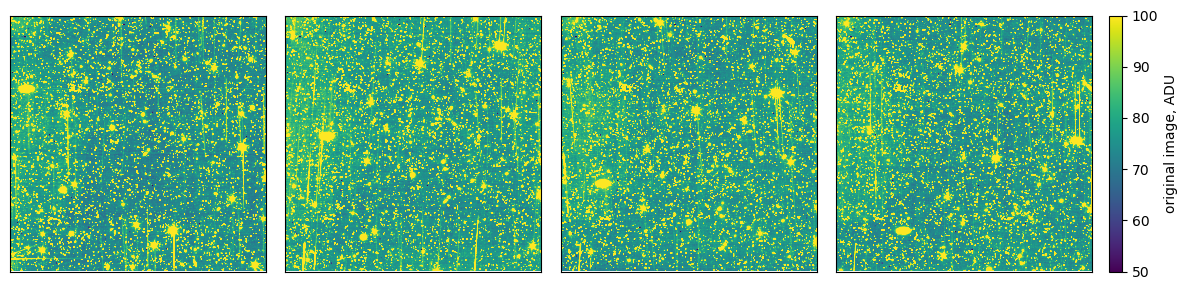

In [ ]:
# |echo: false

fig, ax = plt.subplots(1, 5, figsize=(12, 3), width_ratios=(1, 1, 1, 1, 0.05))
for i in range(4):
    a = ax[i]
    img = fits.getdata(os.path.join(outpath, f"img_{obs_id}_{i}_0_J.fits"), extname=ext)
    aximg = ax[i].imshow(img, vmin=50, vmax=100)
    no_ticks(a)
cbar = plt.colorbar(aximg, cax=ax[-1], label="original image, ADU")
plt.tight_layout()
plt.savefig(os.path.join(outpath, "img.pdf"))

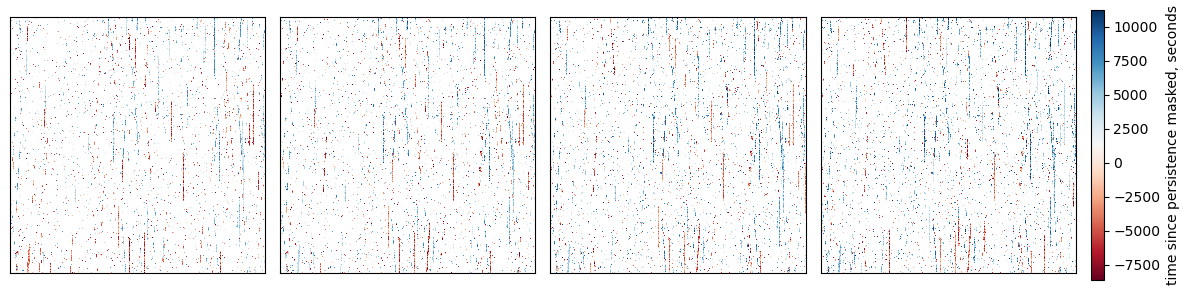

In [ ]:
# |echo: false

fig, ax = plt.subplots(1, 5, figsize=(12, 3), width_ratios=(1, 1, 1, 1, 0.05))
for i in range(4):
    a = ax[i]
    img = fits.getdata(
        os.path.join(outpath, f"dt_lp_{obs_id}_{i}_0_J.fits"), extname=ext
    )
    aximg = a.imshow(
        img, vmin=-0.1 * 86400, vmax=0.13 * 86400, cmap="RdBu", interpolation="none"
    )
    no_ticks(a)
cbar = plt.colorbar(aximg, cax=ax[-1], label="time since persistence masked, seconds")
plt.tight_layout()
plt.savefig(os.path.join(outpath, "dt_lp.pdf"))

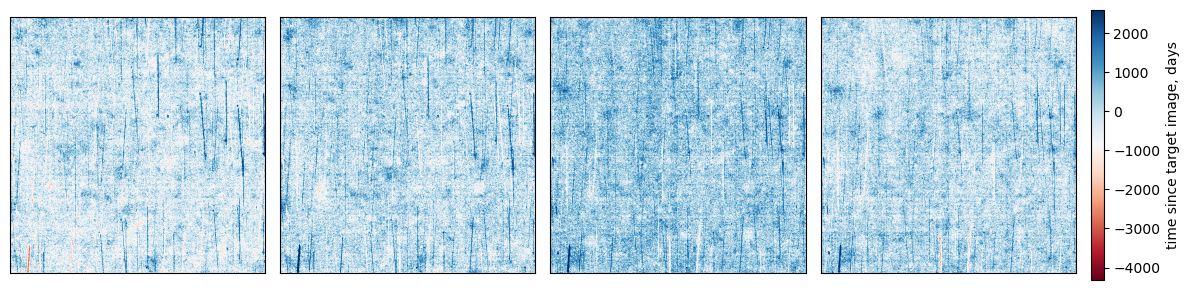

In [ ]:
# |echo: false

fig, ax = plt.subplots(1, 5, figsize=(12, 3), width_ratios=(1, 1, 1, 1, 0.05))
for i in range(4):
    a = ax[i]
    img = fits.getdata(os.path.join(outpath, f"dt_{obs_id}_{i}_0_J.fits"), extname=ext)
    aximg = a.imshow(img, vmin=-0.05 * 86400, vmax=0.03 * 86400, cmap="RdBu")
    no_ticks(a)
cbar = plt.colorbar(aximg, cax=ax[-1], label="time since target image, days")
plt.tight_layout()
plt.savefig(os.path.join(outpath, "dt.pdf"))

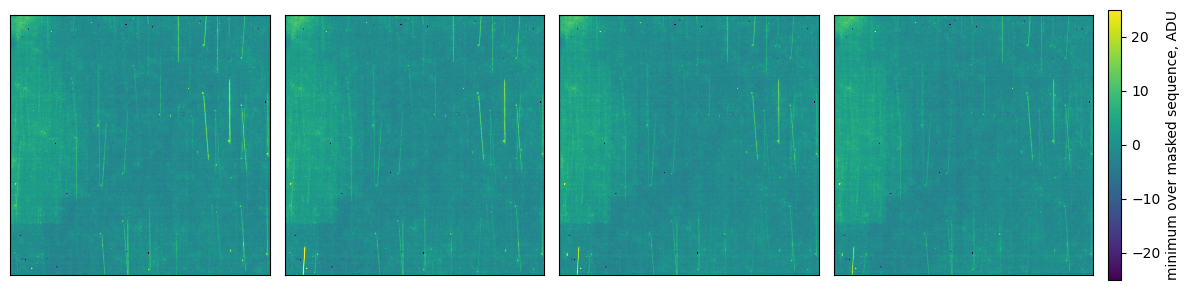

In [ ]:
# |echo: false

fig, ax = plt.subplots(1, 5, figsize=(12, 3), width_ratios=(1, 1, 1, 1, 0.05))
for i in range(4):
    a = ax[i]
    img = fits.getdata(os.path.join(outpath, f"min_{obs_id}_{i}_0_J.fits"), extname=ext)
    aximg = ax[i].imshow(img, vmin=-25, vmax=25)
    no_ticks(a)
cbar = plt.colorbar(aximg, cax=ax[-1], label="minimum over masked sequence, ADU")
plt.tight_layout()
plt.savefig(os.path.join(outpath, "min.pdf"))

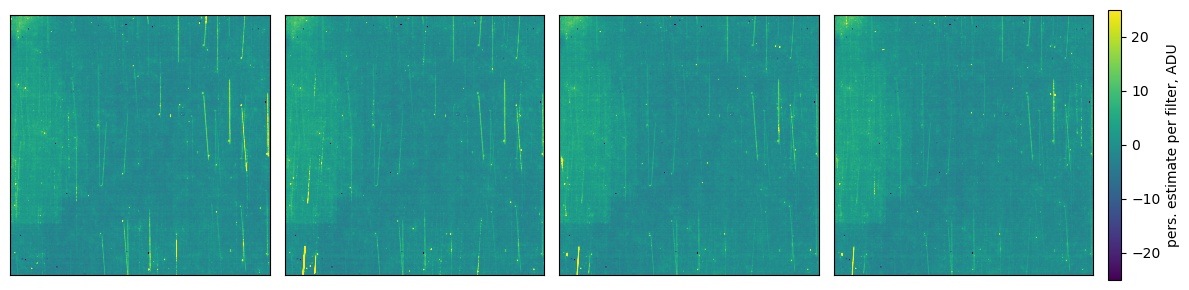

In [ ]:
# |echo: false

fig, ax = plt.subplots(1, 5, figsize=(12, 3), width_ratios=(1, 1, 1, 1, 0.05))
for i in range(4):
    a = ax[i]
    img = fits.getdata(
        os.path.join(outpath, f"corr_{obs_id}_{i}_0_J.fits"), extname=ext
    )
    aximg = ax[i].imshow(img, vmin=-25, vmax=25)
    no_ticks(a)
cbar = plt.colorbar(aximg, cax=ax[-1], label="pers. estimate per filter, ADU")
plt.tight_layout()
plt.savefig(os.path.join(outpath, "corr.pdf"))

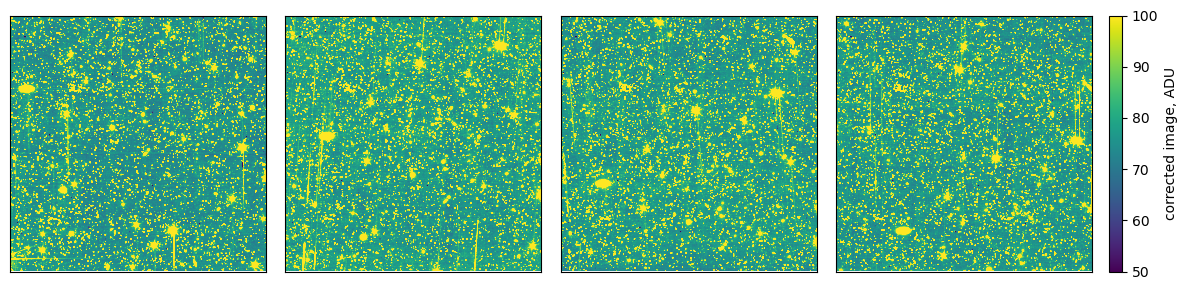

In [ ]:
# |echo: false

fig, ax = plt.subplots(1, 5, figsize=(12, 3), width_ratios=(1, 1, 1, 1, 0.05))
for i in range(4):
    a = ax[i]
    fn = glob(os.path.join(outpath, f"EUC_NIR_W-CAL-IMAGE_J-{obs_id}-{i}*"))[0]
    img = fits.getdata(fn, extname=ext)
    aximg = ax[i].imshow(img, vmin=50, vmax=100)
    no_ticks(a)
cbar = plt.colorbar(aximg, cax=ax[-1], label="corrected image, ADU")
plt.tight_layout()
plt.savefig(os.path.join(outpath, "corrimg.pdf"))

In [ ]:
# | hide
import nbdev

nbdev.nbdev_export()